# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import jarque_bera, mannwhitneyu
import seaborn as sns

from src.config import INTERIM_DATA_DIR

In [ ]:
# Load the dataset
df = pd.read_parquet(INTERIM_DATA_DIR / "video_performance.parquet")
comment_sentiment_df = pd.read_parquet(INTERIM_DATA_DIR / "comment_sentiment.parquet")

# The Integrity & Sanity Check

In [24]:
df.sample(10)

,video_id,title,video_format,content_pillar,publish_year,publish_month,video_age_cohort,video_age_days,lifetime_engagement_rate,marginal_engagement_rate,daily_view_velocity,positive_sentiment_percentage
1443,Kw4UHNnilPY,[Stray Kids : SKZ-TALKER GO! Season 5] Ep.19 A...,Long-form,SKZ-TALKER GO!,2025,7,Catalog (6-24 Months),326,0.108575,0.022172,363.808152,90.099010
1693,GTGdRFRabDo,#현진 의 #락챌린지 #LALALALA_Challenge 🤘 w/ #ITZY #YE...,Short,ROCK-STAR Era,2024,1,Legacy (2+ Years),879,0.114684,0.063531,2357.537561,95.081967
1011,0im5OGhn5_c,"Stray Kids ""神메뉴(God's Menu)"" Dance Practice Vi...",Long-form,Dance & Performance,2020,12,Legacy (2+ Years),2006,0.098703,0.035761,470.394080,59.340659
1332,uwLBNkJ1bY4,"Stray Kids ""CEREMONY"" Dance Practice Video (Ma...",Long-form,Dance & Performance,2025,8,Catalog (6-24 Months),290,0.079381,0.017581,2576.405639,90.789474
1848,fsp7O-XIly0,"Stray Kids ""MAXIDENT"" Album Unboxing",Long-form,Other/Music Videos,2022,10,Legacy (2+ Years),1346,0.137602,0.043478,131.611003,72.500000
240,JVM65SjoZSw,"Stray Kids ""ESCAPE (Bang Chan & Hyunjin)"" Vide...",Long-form,Making Film,2025,3,Catalog (6-24 Months),440,0.138556,0.044607,349.295786,87.096774
523,Y5yvC_NEjT4,[SPOT KIDS : BLACK] 긴박한 현장의 Stray Kids와 명사수 현진!,Long-form,SPOT KIDS,2018,1,Legacy (2+ Years),3074,0.153716,0.105820,52.120450,67.142857
964,HiMJR4SZ2r0,[Two Kids Room(투키즈룸)] VOL.5 Ep.07 Bang Chan X ...,Long-form,Kids Room Series,2019,11,Legacy (2+ Years),2414,0.095176,0.072254,35.780879,60.294118
379,GWSH0W3IcYs,[SKZ VLOG] I.N : I.N의 퐁당로그 9 in Busan & London,Long-form,Vlogs & Logs,2025,4,Catalog (6-24 Months),422,0.129799,0.032765,287.213312,74.766355
600,Vu23Rnu6SzU,[SKZ VLOG] Changbin : 돼끼의 꿀로그,Long-form,Vlogs & Logs,2020,8,Legacy (2+ Years),2134,0.163535,0.049505,45.260714,75.308642


In [25]:
df_sentiment_result.sample(5)

,video_id,comment_id,text,language,sentiment_label
143360,dR9HdopWZzI,UgypJOtyS6jmFe26aeZ4AaABAg,"Changbin rocked it, you dance beautifully, you...",eng_Latn,positive
152123,qfbEDtYuaEA,UgyURa_03yvq-btxdm94AaABAg,Their footsteps about to cause an earthquake i...,eng_Latn,positive
127167,uL47tVkagHg,UgyfWFyPVegZTqZYYph4AaABAg,When there is no English captions so you just ...,eng_Latn,positive
179223,fs9zzKkeyuE,UgzEvFV5h3ETS-yC28h4AaABAg,WHY IS NOBODY TALKING ABOUT HOW GOOD MINHO LOO...,eng_Latn,positive
123412,QIoHz-ZD9WQ,Ugydnnjh5PWhmQTuAv54AaABAg,당신은 정말 대단해요,kor_Hang,positive


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2086 entries, 0 to 2085
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   video_id                       2086 non-null   str     
 1   title                          2086 non-null   str     
 2   video_format                   2086 non-null   category
 3   content_pillar                 2086 non-null   category
 4   publish_year                   2086 non-null   uint16  
 5   publish_month                  2086 non-null   uint8   
 6   video_age_cohort               2086 non-null   category
 7   video_age_days                 2086 non-null   uint16  
 8   lifetime_engagement_rate       2086 non-null   float64 
 9   marginal_engagement_rate       2086 non-null   float64 
 10  daily_view_velocity            2086 non-null   float64 
 11  positive_sentiment_percentage  2079 non-null   float64 
dtypes: category(3), float64(4), str(2), uint16(2)

In [ ]:
comment_sentiment_df.groupby("video_id")["text"].count().sort_values(ascending=False)

video_id
jrjmw5uPjyY    324
F0UIsSnotlA    285
l8sSQAa1kNM    284
Oswujxm2Ag0    255
IxMAU-t_0tw    234
              ... 
N4TvZEitC-0     62
dlFM8CI2wjM     62
JWh7gr-e84k     61
PSdAXuUDNpo     59
zTkwIgT64ow     57
Name: text, Length: 2079, dtype: int64

In [28]:
# 1. Check for missing values or infinite numbers
print("Missing Values:")
print(df.isnull().sum())

print("\nInfinite Numbers: ")
print(df.isin([np.inf, -np.inf]).sum())

Missing Values:
video_id                         0
title                            0
video_format                     0
content_pillar                   0
publish_year                     0
publish_month                    0
video_age_cohort                 0
video_age_days                   0
lifetime_engagement_rate         0
marginal_engagement_rate         0
daily_view_velocity              0
positive_sentiment_percentage    7
dtype: int64

Infinite Numbers: 
video_id                         0
title                            0
video_format                     0
content_pillar                   0
publish_year                     0
publish_month                    0
video_age_cohort                 0
video_age_days                   0
lifetime_engagement_rate         0
marginal_engagement_rate         0
daily_view_velocity              0
positive_sentiment_percentage    0
dtype: int64


***Note:*** Missing values are present in Column `positive_sentiment_percentage` due to the fact that some videos have no comments. Thus, further analysis are not needed to be done on those videos.

# Univariate Analysis
## Statistical Summary

In [4]:
df.describe()

,publish_year,publish_month,video_age_days,lifetime_engagement_rate,marginal_engagement_rate,daily_view_velocity,positive_sentiment_percentage
count,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2079.000000
mean,2022.927133,7.334612,1078.962128,0.118474,0.023550,3644.109083,81.728040
std,2.340236,3.348821,855.476083,0.054052,0.049550,15164.686468,12.401391
min,2018.000000,1.000000,1.000000,0.010731,-0.508834,4.481257,26.966292
25%,2021.000000,5.000000,345.250000,0.081167,0.007703,101.138040,74.222777
50%,2024.000000,8.000000,764.000000,0.108808,0.028743,293.177557,84.761905
75%,2025.000000,10.000000,1648.750000,0.144967,0.047235,1401.814460,91.440781
max,2026.000000,12.000000,3082.000000,0.373373,0.225804,293319.170160,100.000000


## Distribution

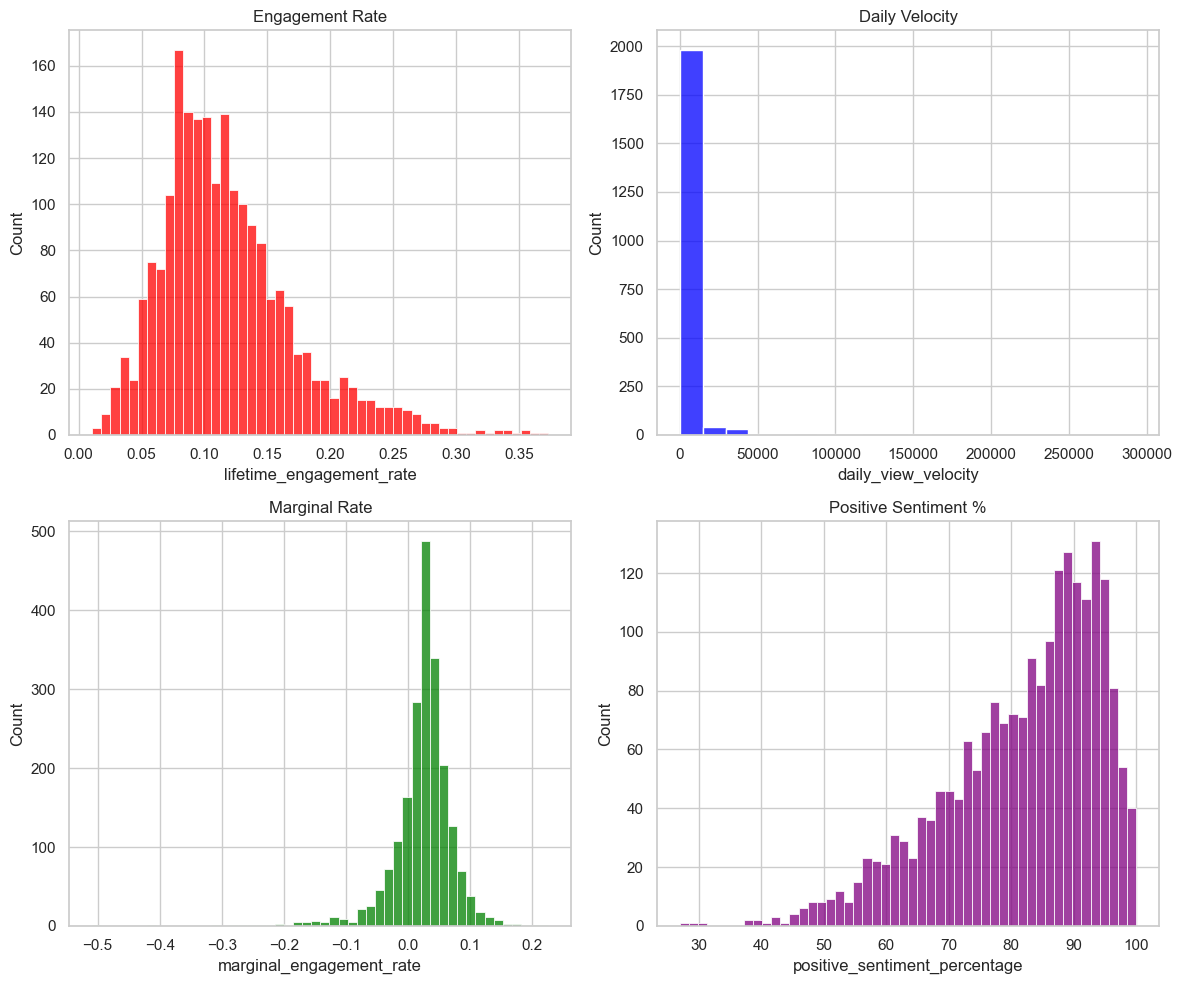

In [31]:
# Set the visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot distributions
sns.histplot(df, x="lifetime_engagement_rate", bins=50, ax=axes[0,0], color="red").set_title("Engagement Rate")
sns.histplot(df, x="daily_view_velocity", bins=20, ax=axes[0,1], color="blue").set_title("Daily Velocity")
sns.histplot(df, x="marginal_engagement_rate", bins=50, ax=axes[1,0], color="green").set_title("Marginal Rate")
sns.histplot(df, x="positive_sentiment_percentage", bins=50, ax=axes[1,1], color="purple").set_title("Positive Sentiment %")

plt.tight_layout()
plt.show()

## Normality Test

In [32]:
# Select only numeric columns
numerical_cols = ["video_age_days", "lifetime_engagement_rate", 
                  "marginal_engagement_rate", "daily_view_velocity", "positive_sentiment_percentage"]

col_name_list, stat_val_list, p_val_list, is_norm_list = [], [], [], []
for col_name in numerical_cols:
    jb_result = jarque_bera(df[col_name].dropna())
    stat_val = jb_result.statistic # type: ignore
    p_val = jb_result.pvalue # type: ignore
    if p_val <= 0.05:
        is_norm_list.append(False)
    else:
        is_norm_list.append(True)
    
    col_name_list.append(col_name)
    stat_val_list.append(stat_val)
    p_val_list.append(p_val)
    
normality_result = pd.DataFrame({
    "column": col_name_list,
    "stat_value": stat_val_list,
    "p_value": p_val_list,
    "is_norm": is_norm_list
})

normality_result

,column,stat_value,p_value,is_norm
0,video_age_days,2.474825e+02,1.819091e-54,False
1,lifetime_engagement_rate,7.164705e+02,2.632711e-156,False
2,marginal_engagement_rate,1.920589e+04,0.000000e+00,False
3,daily_view_velocity,1.231984e+06,0.000000e+00,False
4,positive_sentiment_percentage,3.124889e+02,1.392822e-68,False


***Notes:*** 
* `daily_view_velocity` is heavily clumped to the left with a long tail to the right (right-skewed) due to some videos just being released and having a high number of views in the first few days, while most videos have a much lower daily view velocity. A future Machine Learning model will struggle to predict it.
* None of the numeric columns follow a normal distribution, and thus, a transformation is probably needed to make them more normally distributed.
* Apply a Log Transformation to these numeric columns when moving to the modeling phase.

# Categorical Deep Dive
*Which content pillars perform best?*

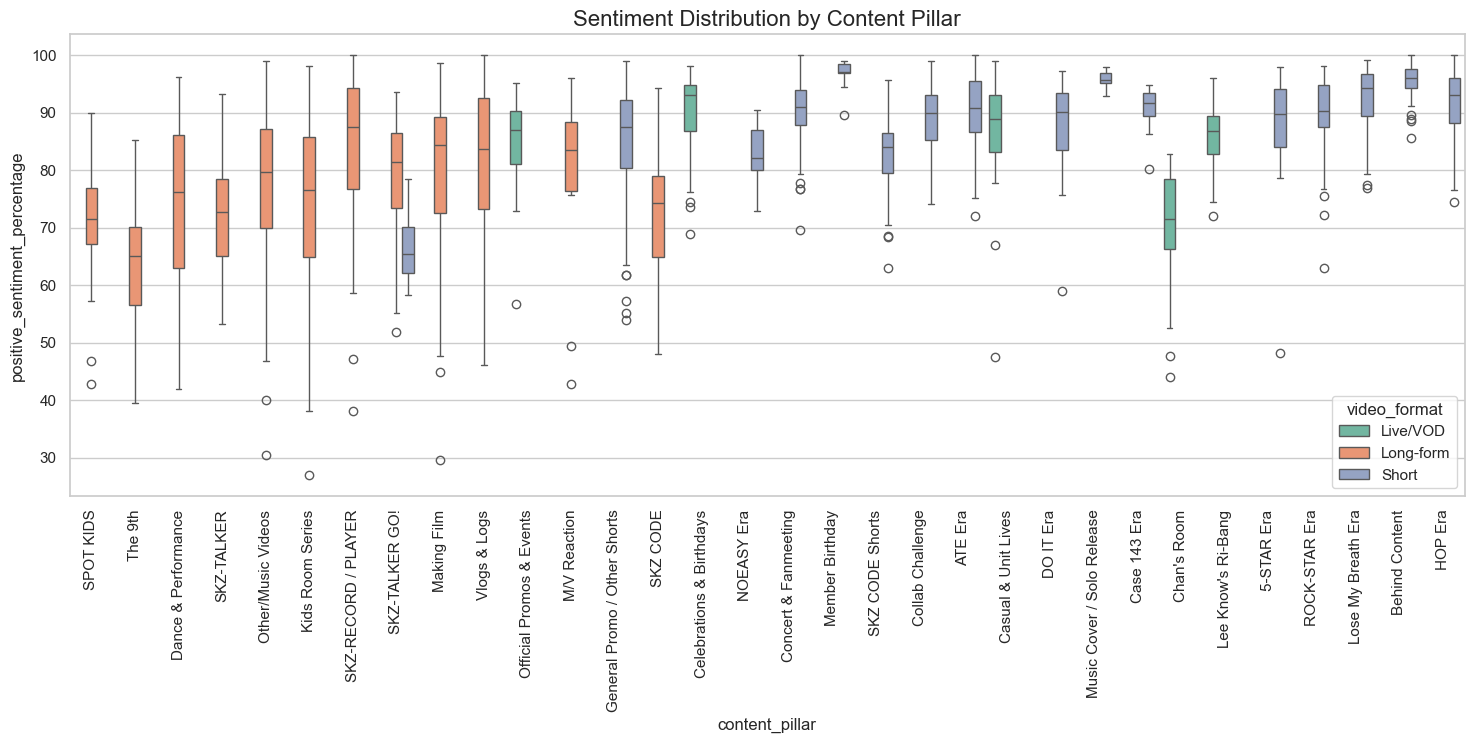

In [33]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df, x="content_pillar", y="positive_sentiment_percentage", palette="Set2", hue="video_format")
plt.title("Sentiment Distribution by Content Pillar", fontsize=16)
plt.xticks(rotation=90)
plt.show()

***Notes:***
* `SKZ-RECORD/PLAYER`, `Vlogs & Logs`, and `Making Film` videos show higher positive sentiment percentage compared to other long-form videos, but they also have high variance.
* `M/V Reaction` videos also have higher positive sentiment percentage compared to other long-form videos, but they have lower variance.

# Bivariate Analysis

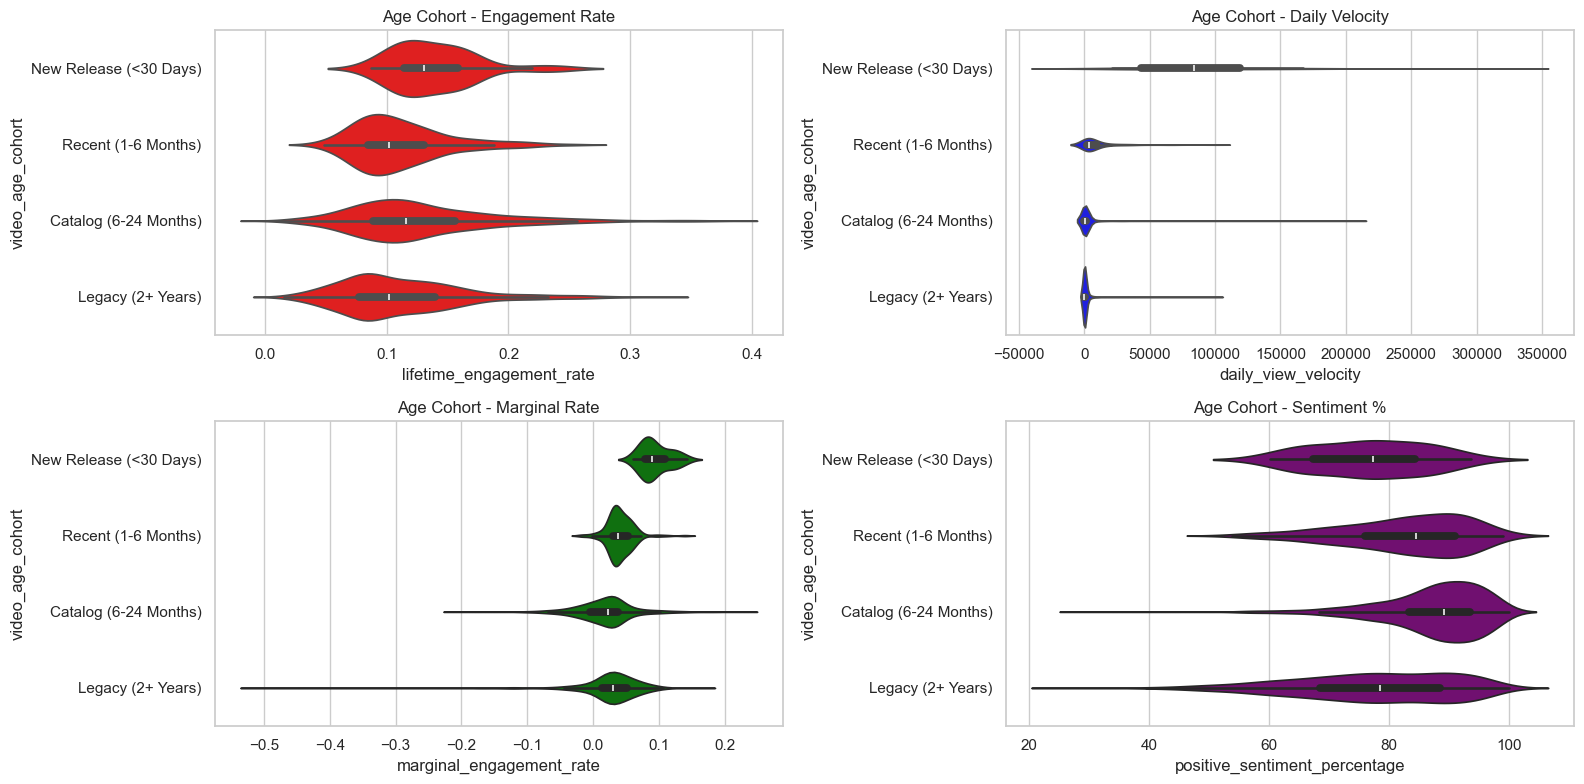

In [35]:
# Set the visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

sns.violinplot(df, x="lifetime_engagement_rate", y="video_age_cohort", ax=axes[0,0], color="red").set_title("Age Cohort - Engagement Rate")
sns.violinplot(df, x="daily_view_velocity", y="video_age_cohort", ax=axes[0,1], color="blue").set_title("Age Cohort - Daily Velocity")
sns.violinplot(df, x="marginal_engagement_rate", y="video_age_cohort", ax=axes[1,0], color="green").set_title("Age Cohort - Marginal Rate")
sns.violinplot(df, x="positive_sentiment_percentage", y="video_age_cohort", ax=axes[1,1], color="purple").set_title("Age Cohort - Sentiment %")

plt.tight_layout()
plt.show()

In [ ]:
# Filter old videos that have high marginal engagement rates relative to the new videos' average marginal engagement rate
recent_avg_marginal_eng_rate = df[df["video_age_cohort"] == "New Release (<30 Days)"].astype({"video_age_cohort": "str"})["marginal_engagement_rate"].mean()

df[(df["video_age_cohort"] == "Legacy (2+ Years)") & (df["marginal_engagement_rate"] >= recent_avg_marginal_eng_rate)]

,video_id,title,video_format,content_pillar,publish_year,publish_month,video_age_cohort,video_age_days,lifetime_engagement_rate,marginal_engagement_rate,daily_view_velocity,positive_sentiment_percentage
125,Rj4rhKrQ7x0,💥💫🔦✌ #StrayKids #스트레이키즈 #방찬 #BangChan #현진 #Hyu...,Short,General Promo / Other Shorts,2024,6,Legacy (2+ Years),722,0.174644,0.124347,3041.338302,81.343284
523,Y5yvC_NEjT4,[SPOT KIDS : BLACK] 긴박한 현장의 Stray Kids와 명사수 현진!,Long-form,SPOT KIDS,2018,1,Legacy (2+ Years),3074,0.153716,0.105820,52.120450,67.142857
528,sYEL-L3jDpM,[SPOT KIDS : BLACK] Stray Kids 멤버들의 셀카 비법 전수 타임!,Long-form,SPOT KIDS,2018,4,Legacy (2+ Years),2982,0.140201,0.097152,20.579305,68.571429
532,cbAi_0kzqvE,[SPOT KIDS : BLACK] 비니지니의 초!밀착 Talk (feat. 아무말파티),Long-form,SPOT KIDS,2018,6,Legacy (2+ Years),2929,0.145475,0.112523,18.993630,76.811594
558,6IKQjkR05Vs,[SPOT KIDS : BLACK] SKZ&SKZ(슼과 슼) Teaser Behin...,Long-form,SPOT KIDS,2018,12,Legacy (2+ Years),2737,0.122329,0.099415,11.789082,73.846154
655,STDBI3xPhtU,[SPOT KIDS : BLACK] Stray Kids의 혼란 속 가위바-보,Long-form,SPOT KIDS,2018,5,Legacy (2+ Years),2962,0.126663,0.094737,26.198110,73.437500
657,oLvoI2C_OFQ,[SPOT KIDS : BLACK] 꼼지락꼼지락 Stray Kids의 눕방 비하인드!,Long-form,SPOT KIDS,2018,6,Legacy (2+ Years),2935,0.130301,0.095683,29.541816,82.089552
665,Cw5U39pu5nU,[SPOT KIDS : BLACK] 알콩달콩 슼둥이들의 리얼한 대기실 모습 대공개!,Long-form,SPOT KIDS,2018,10,Legacy (2+ Years),2800,0.136364,0.098280,14.029782,75.714286
675,7_J-cnAvMmA,[Stray Kids : SKZ&SKZ(슼과 슼)] Ep.04,Long-form,Other/Music Videos,2018,11,Legacy (2+ Years),2760,0.098217,0.094180,32.575293,84.507042
775,7Yz183XU64E,"[SPOT KIDS : BLACK] 세상 신난 삼뿜이들의 ""뿜뿜"" 촬영가는 길♬",Long-form,SPOT KIDS,2018,6,Legacy (2+ Years),2915,0.148126,0.097070,18.821274,87.179487


In [5]:
# Identify videos with massive `daily_view_velocity`, relative to the average, but a negative or near-zero `marginal_engagement_rate`
avg_daily_velocity = df["daily_view_velocity"].mean()

df[(df["daily_view_velocity"] > avg_daily_velocity) & (df["marginal_engagement_rate"] <= 0)]

,video_id,title,video_format,content_pillar,publish_year,publish_month,video_age_cohort,video_age_days,lifetime_engagement_rate,marginal_engagement_rate,daily_view_velocity,positive_sentiment_percentage


***Notes:***
* 25 legacy videos are found with `marginal_engagement_rate` that is significantly above the average of new release (<30 days) videos. This signals old videos like variety shows going viral again due to a trend, meme, or recent comeback mention.
* There are no videos with massive `daily_view_velocity` but a negative or near-zero `marginal_engagement_rate` that are found.

# Multivariate Analysis

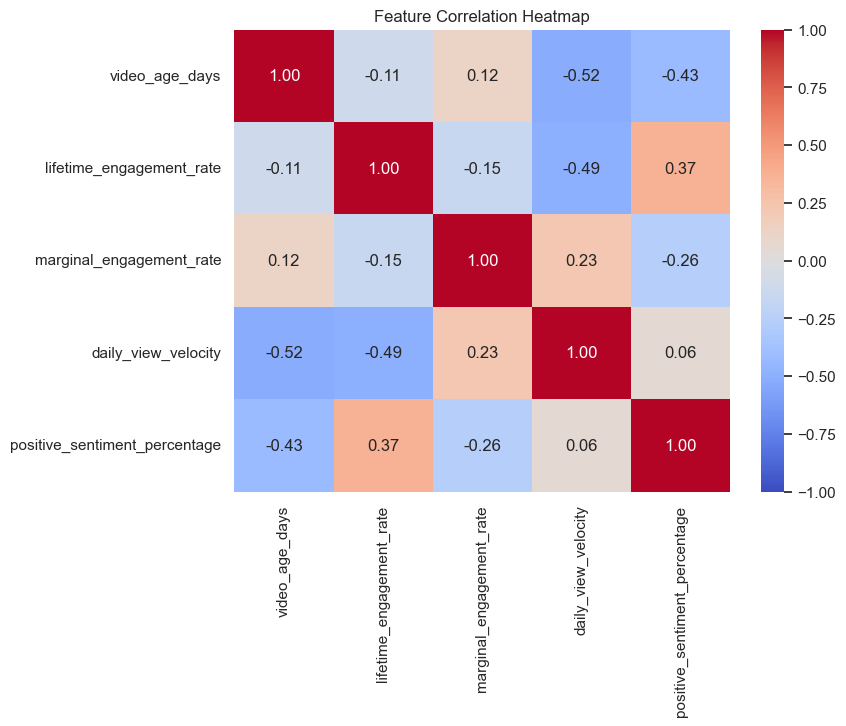

In [41]:
# Select only numerical columns
numerical_cols = ["video_age_days", "lifetime_engagement_rate", 
                  "marginal_engagement_rate", "daily_view_velocity", "positive_sentiment_percentage"]

corr_matrix = df[numerical_cols].dropna().corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

****Notes:*** 
* Features tend to have very low to moderate correlation with each other.
* `video_age_days` and `daily_view_velocity` have a moderate negative correlation, which is expected as older videos tend to have lower daily view velocity.
* `video_age_days` and `positive_sentiment_percentage` have a moderate negative correlation, which is expected as older videos tend to have lower positive sentiment percentage.
* `daily_view_velocity` and `lifetime_engagement_rate` have a moderate negative correlation, which is expected as videos with higher daily view velocity tend to have lower lifetime engagement rate.

In [13]:
list(df[df["video_format"] == "Long-form"]["content_pillar"].unique())

['Dance & Performance',
 'SKZ CODE',
 'Making Film',
 'SKZ-TALKER',
 'Kids Room Series',
 'Other/Music Videos',
 'SKZ-RECORD / PLAYER',
 'Vlogs & Logs',
 'SKZ-TALKER GO!',
 'M/V Reaction',
 'SPOT KIDS',
 'The 9th']

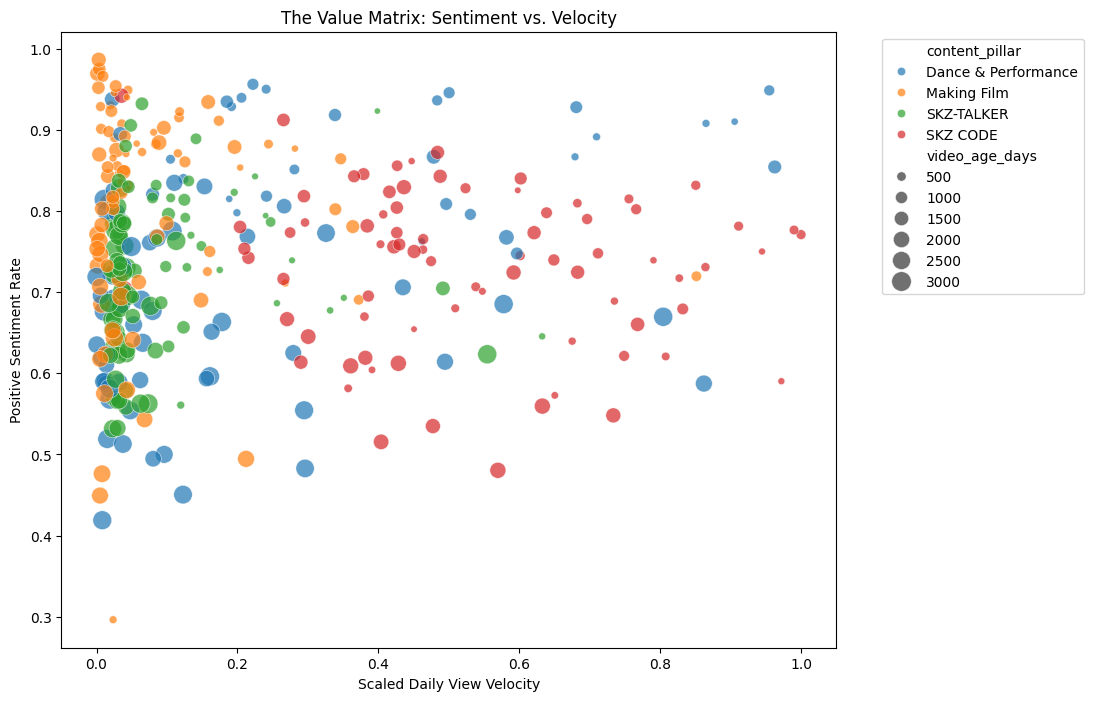

In [28]:
df_scattered = (
    df[
        (df["video_format"] == "Long-form") &
        (df["daily_view_velocity"] <= 3000) &
        (df["content_pillar"].isin([
            'Dance & Performance',
            'SKZ CODE',
            'Making Film',
            'SKZ-TALKER'
        ]))
    ].astype({"content_pillar": "str"})
)

# Scale `daily_view_velocity` and `positive_sentiment_percentage`
df_scattered["daily_view_velocity"] = (
    (df_scattered["daily_view_velocity"] - df_scattered["daily_view_velocity"].min())
    / (df_scattered["daily_view_velocity"].max() - df_scattered["daily_view_velocity"].min())
)

df_scattered["positive_sentiment_percentage"] = df_scattered["positive_sentiment_percentage"] / 100

plt.figure(figsize=(10, 8))
sns.scatterplot(x="daily_view_velocity", 
                y="positive_sentiment_percentage", 
                hue="content_pillar", 
                size="video_age_days",
                sizes=(20, 200),
                alpha=0.7,
                data=df_scattered)

plt.title("The Value Matrix: Sentiment vs. Velocity")
plt.xlabel("Scaled Daily View Velocity")
plt.ylabel("Positive Sentiment Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

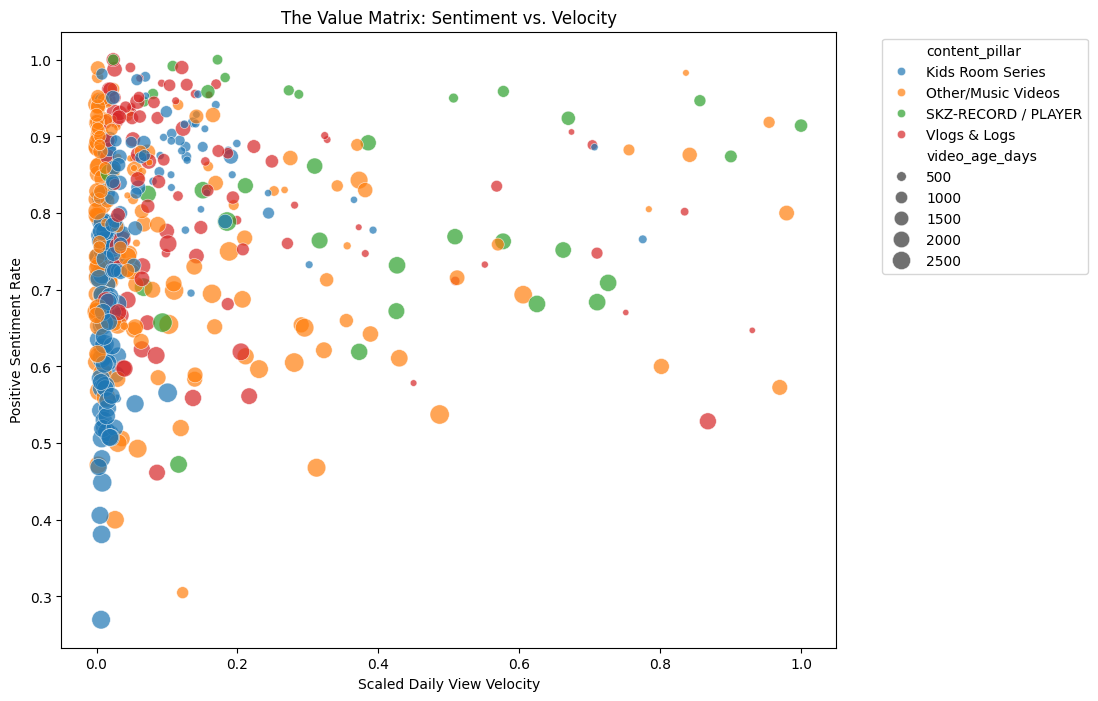

In [29]:
df_scattered = (
    df[
        (df["video_format"] == "Long-form") &
        (df["daily_view_velocity"] <= 3000) &
        (df["content_pillar"].isin([
            'Kids Room Series',
            'Other/Music Videos',
            'SKZ-RECORD / PLAYER',
            'Vlogs & Logs'
        ]))
    ].astype({"content_pillar": "str"})
)

# Scale `daily_view_velocity` and `positive_sentiment_percentage`
df_scattered["daily_view_velocity"] = (
    (df_scattered["daily_view_velocity"] - df_scattered["daily_view_velocity"].min())
    / (df_scattered["daily_view_velocity"].max() - df_scattered["daily_view_velocity"].min())
)

df_scattered["positive_sentiment_percentage"] = df_scattered["positive_sentiment_percentage"] / 100

plt.figure(figsize=(10, 8))
sns.scatterplot(x="daily_view_velocity", 
                y="positive_sentiment_percentage", 
                hue="content_pillar", 
                size="video_age_days",
                sizes=(20, 200),
                alpha=0.7,
                data=df_scattered)

plt.title("The Value Matrix: Sentiment vs. Velocity")
plt.xlabel("Scaled Daily View Velocity")
plt.ylabel("Positive Sentiment Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

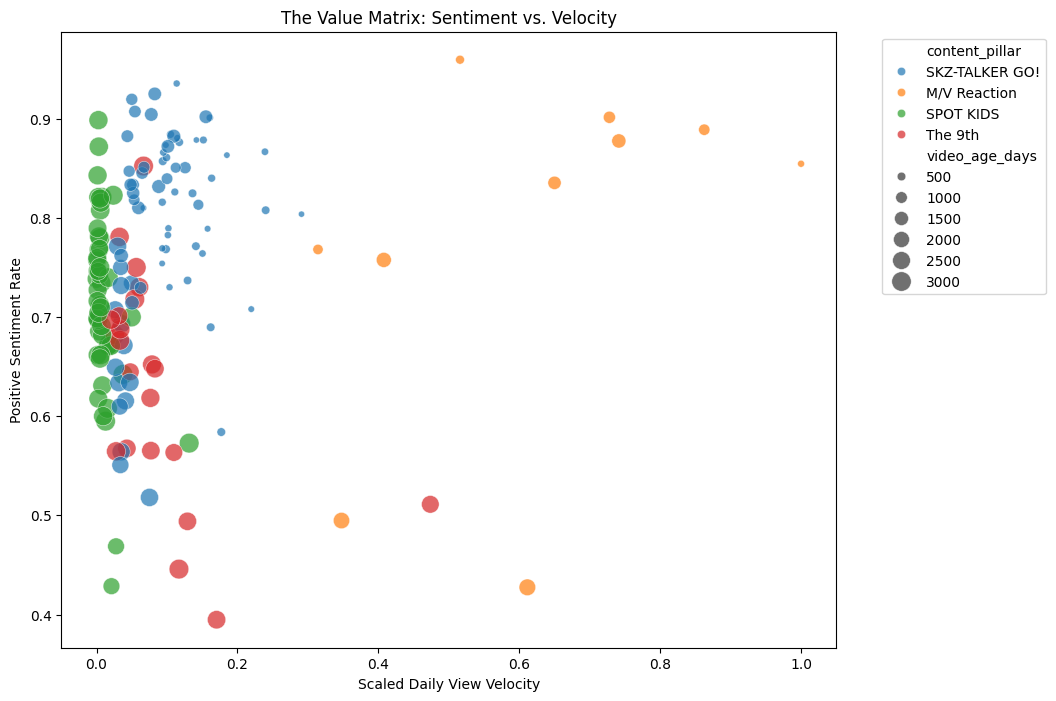

In [30]:
df_scattered = (
    df[
        (df["video_format"] == "Long-form") &
        (df["daily_view_velocity"] <= 3000) &
        (df["content_pillar"].isin([
            'SKZ-TALKER GO!',
            'M/V Reaction',
            'SPOT KIDS',
            'The 9th'
        ]))
    ].astype({"content_pillar": "str"})
)

# Scale `daily_view_velocity` and `positive_sentiment_percentage`
df_scattered["daily_view_velocity"] = (
    (df_scattered["daily_view_velocity"] - df_scattered["daily_view_velocity"].min())
    / (df_scattered["daily_view_velocity"].max() - df_scattered["daily_view_velocity"].min())
)

df_scattered["positive_sentiment_percentage"] = df_scattered["positive_sentiment_percentage"] / 100

plt.figure(figsize=(10, 8))
sns.scatterplot(x="daily_view_velocity", 
                y="positive_sentiment_percentage", 
                hue="content_pillar", 
                size="video_age_days",
                sizes=(20, 200),
                alpha=0.7,
                data=df_scattered)

plt.title("The Value Matrix: Sentiment vs. Velocity")
plt.xlabel("Scaled Daily View Velocity")
plt.ylabel("Positive Sentiment Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [42]:
df_sentiment_result[df_sentiment_result["sentiment_label"] == "negative"].sample(10)

,video_id,comment_id,text,language,sentiment_label
56317,MI6_aH1JT7s,Ugx0tsbzuxQZBPYZurh4AaABAg,The editors are so diabolical at one point dur...,eng_Latn,negative
159026,XHZJY-H-I7U,UgyyVGY3pG6AaSEg4Ox4AaABAg,chan be like: its so hard being a solo parent ...,eng_Latn,negative
63619,To0w8Qh7kVo,Ugx9UKTJb728qd129lt4AaABAg,すんちゃんの涙見て胸がキュッとなった😥\n泣かずに見る自信がないわー😢,jpn_Jpan,negative
67744,lhgbl7ENZSY,UgxcD39KGF0VP-pGBGF4AaABAg,살벌하게 생겼다 이리노,kor_Hang,negative
35656,x-kl7fzEmaY,UgwP8QLOanpiLWqeDER4AaABAg,HOW DARE YOUTUBE HIDING THIS 3 MINUTES?!?!,yue_Hant,negative
181926,lldrm_7fVP0,UgzgI5N4NHVRj-2VZj94AaABAg,콘서트 가고 싶다ㅜ,kor_Hang,negative
70326,vPTFGiybrzA,UgxDUcxR2nhpSaJihal4AaABAg,but it must be soo uncomfortable for them cuz ...,eng_Latn,negative
161897,dtV1I9WtQuo,Ugz_2RIEpvs93NniW-B4AaABAg,"when I listened to it, it was ""three minutes"" ...",eng_Latn,negative
213041,bY_TqcsMyHM,Ugzz6i9AHnCMHoQlSr54AaABAg,Girls dont want boyfriend they just want hyunj...,eng_Latn,negative
193870,qqUKjw5-JSQ,UgznnWXfU-YMDWM_cb94AaABAg,WE NEED MORE DANCER LEEKNOW CONTENT 💔,yue_Hant,negative


***Note:*** Upon plotting the min-max scaled `daily_view_velocity` against `positive_sentiment_percentage`, no distinct clustering of content pillars was observed.

# Mann-Whitney U Test
Comparing `lifetime_engagement_rate` between `video_format` categories, "Long-form" and "Short".

In [ ]:
# Define two independent sample groups
eng_rate_lf = df[df["video_format"] == "Long-form"]["lifetime_engagement_rate"]
eng_rate_short = df[df["video_format"] == "Short"]["lifetime_engagement_rate"]

# Perform the Mann-Whitney U test
# Hypothesis: The two distributions are different (Long-form Videos ≠ Short Videos)
u_statistic, p_value = mannwhitneyu(eng_rate_lf, eng_rate_short, alternative='two-sided')

# Print the metrics
print(f"U-statistic: {u_statistic}")
print(f"p-value:     {p_value}")

# Interpret the final results
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the null hypothesis (significant difference between the groups).")
else:
    print("Conclusion: Fail to reject the null hypothesis (no significant difference).")


U-statistic: 303497.0
p-value:     1.4545882338197927e-40
Conclusion: Reject the null hypothesis (significant difference between the groups).


In [ ]:
# Perform the Mann-Whitney U test
# Null Hypothesis: Long-form Videos stochastically don't have smaller engagement rates than Short Videos (Long-form Videos >= Short Videos)
u_statistic, p_value = mannwhitneyu(eng_rate_lf, eng_rate_short, alternative='less')

# Print the metrics
print(f"U-statistic: {u_statistic}")
print(f"p-value:     {p_value}")

# Interpret the final results
alpha = 0.05
if p_value < alpha:
    print(f"Conclusion: Reject the null hypothesis.")
else:
    print(f"Conclusion: Fail to reject the null hypothesis.")

U-statistic: 303497.0
p-value:     7.272941169098964e-41
Conclusion: Reject the null hypothesis.


***Note:*** The Mann-Whitney U test strongly rejects the null hypothesis that long-form video engagement is equal to or greater than short-form video engagement (U = 303,497.0, p ≈ 7.27 × 10⁻⁴¹, α = 0.05)

# Velocity Decay Analysis
Transforming arbitrary age boundaries into mathematically proven lifecycle stages for `SKZ-RECORD/PLAYER`, `Vlogs & Logs`, `Making Film`, `M/V Reaction`, and `Other/Music Videos` content pillars. This represents exactly how many days it takes for a content pillar's active streaming velocity to drop by half using the formula below.

$$V(t) = V_0 \cdot e^{-\lambda t} + c$$

In [6]:
# Define the exponential decay function
def exponential_decay(t, V0, lam, c):
    return V0 * np.exp(-lam * t) + c

In [11]:
list(df[df["video_format"] == "Long-form"]["content_pillar"].unique())

['Dance & Performance',
 'SKZ CODE',
 'Making Film',
 'SKZ-TALKER',
 'Kids Room Series',
 'Other/Music Videos',
 'SKZ-RECORD / PLAYER',
 'Vlogs & Logs',
 'SKZ-TALKER GO!',
 'M/V Reaction',
 'SPOT KIDS',
 'The 9th']

In [ ]:
lf_content_pillars = ["SKZ-RECORD / PLAYER", "Vlogs & Logs", "Making Film", "M/V Reaction", "Other/Music Videos"]

for lf_content_pillar in lf_content_pillars:
    # Filter data
    pillar_df = df[df["lf_content_pillar"] == lf_content_pillar].dropna(subset=["video_age_days", "daily_view_velocity"])

    x_data = pillar_df["video_age_days"].values
    y_data = pillar_df["daily_view_velocity"].values

    # Fit the curve
    popt, pcov = curve_fit(exponential_decay, x_data, y_data, p0=[max(y_data), 0.05, min(y_data)], bounds=(0, np.inf))

    V0_fit, lam_fit, c_fit = popt
    half_life = np.log(2) / lam_fit

    print("--------------------------------------------------")
    print(f"Content Pillar              : {lf_content_pillar}")
    print(f"Decay Constant (λ)          : {lam_fit:.4f}")
    print(f"Calculated Content Half-Life: {half_life:.2f} Days\n")

--------------------------------------------------
Content Pillar              : SKZ-RECORD / PLAYER
Decay Constant (λ)          : 0.4032
Calculated Content Half-Life: 1.72 Days

--------------------------------------------------
Content Pillar              : Vlogs & Logs
Decay Constant (λ)          : 0.0850
Calculated Content Half-Life: 8.16 Days

--------------------------------------------------
Content Pillar              : Making Film
Decay Constant (λ)          : 0.0227
Calculated Content Half-Life: 30.56 Days

--------------------------------------------------
Content Pillar              : M/V Reaction
Decay Constant (λ)          : 0.0004
Calculated Content Half-Life: 1613.16 Days

--------------------------------------------------
Content Pillar              : Other/Music Videos
Decay Constant (λ)          : 0.0942
Calculated Content Half-Life: 7.36 Days



In [15]:
# Create a new dataset of content half-life
content_pillars = df["content_pillar"].unique().tolist()
decay_consts_list = []
half_life_list = []

for content_pillar in content_pillars:
    # Filter data
    pillar_df = df[df["content_pillar"] == content_pillar].dropna(subset=["video_age_days", "daily_view_velocity"])

    x_data = pillar_df["video_age_days"].values
    y_data = pillar_df["daily_view_velocity"].values

    # Fit the curve
    popt, pcov = curve_fit(exponential_decay, x_data, y_data, p0=[max(y_data), 0.05, min(y_data)], bounds=(0, np.inf))

    V0_fit, lam_fit, c_fit = popt
    half_life = np.log(2) / lam_fit
    
    # Append values
    decay_consts_list.append(lam_fit)
    half_life_list.append(half_life.round())

content_half_life_df = pd.DataFrame(
    {"content_pillar": content_pillars, "decay_const": decay_consts_list, "half_life": half_life_list}
).astype({"half_life": "uint16"})

In [18]:
content_half_life_df.head()

,content_pillar,decay_const,half_life
0,Dance & Performance,0.034466,20
1,General Promo / Other Shorts,0.034788,20
2,Lose My Breath Era,0.050000,14
3,SKZ CODE,0.038784,18
4,ATE Era,0.178240,4


In [19]:
content_half_life_df.to_parquet(INTERIM_DATA_DIR / "content_half_life.parquet")

# Conclusion
## Findings & Insights
1. **The Format Advantage: Shorts Drive Engagement**
    * **Finding:** Statistical analysis confirms that YouTube Shorts yield a significantly higher engagement rate than Long-form videos.
    * **Insight:** Shorts have a lower "friction" for engagement. The UI is designed for rapid double-tapping (liking) and quick commenting. Furthermore, Shorts are fed through an algorithmic scroll, capturing viewers in a high-dopamine state where they are more prone to engage impulsively compared to a 20-minute vlog requiring sustained attention.

2. **The Evergreen Anchor: M/V Reactions Have Infinite Shelf Life**
    * **Finding:** Based on exponential decay modeling using the formula $V(t) = V_0 \cdot e^{-\lambda t} + c$, "M/V Reaction" videos demonstrate an extraordinary half-life of **1,613 days**, compared to just **1.72 days** for "SKZ-RECORD / PLAYER" content. Furthermore, M/V Reactions boast high and stable positive sentiment (around 85%).
    * **Insight:** M/V Reactions are "companion content." Whenever a fan (new or old) watches an official Music Video, YouTube's algorithm heavily recommends the group's reaction to that same video. This creates an evergreen loop of traffic. Conversely, SKZ-RECORDs are audio-centric releases; core fans rush to stream them immediately upon release (causing a massive initial spike), but replay value drops sharply as fans migrate back to Spotify or Apple Music for audio consumption.

3. **The Legacy Resurgence: Old Catalog is Generating New Heat**
    * **Finding:** 25 legacy videos (published 2+ years ago) are currently outperforming new releases (<30 days) in `marginal_engagement_rate` (momentum).
    * **Insight:** Because our scraping window was May 17th to June 15th, 2026, these older videos are likely being driven by an external catalyst. This is highly indicative of a recent TikTok trend using an older Stray Kids audio snippet, or algorithmic resurfacing due to recent group activities (like the *dominATE* tour) pushing new fans to "binge" the back-catalog. The people watching these old videos right now are highly engaged new fans.

4. **The Viral Dilution Effect: High Views Lower Engagement**
    * **Finding:** There is a moderate negative correlation between `daily_view_velocity` and `lifetime_engagement_rate`. Put simply: the faster a video gains views, the lower its overall engagement rate becomes.
    * **Insight:** This is the classic "Echo Chamber vs. Mainstream" effect. When a video first drops, the hardcore fanbase (STAYs) watches, likes, and comments immediately—creating a massive engagement rate. As a video goes viral and view velocity increases, it reaches the "General Public." Casual viewers will watch a video, but they rarely like or comment, which mathematically dilutes the engagement rate. Additionally, older videos tend to attract lower positive sentiment because they eventually reach viewers outside the core fandom who may leave neutral or critical comments.


## Actionable Recommendations

1. **Deploy a "Companion Content" Strategy:** Given that M/V Reactions have a 1,600+ day half-life with high sentiment, the team should mandate reaction videos for *every* major release. Consider expanding this format to include "Performance Video Reactions" or "Dance Practice Reactions" to create more evergreen algorithmic loops.
2. **Investigate the "Legacy 25":** The marketing team must immediately review the 25 legacy videos showing high marginal engagement. Identify what is causing their resurgence (e.g., a specific meme, a TikTok audio trend). Once identified, capitalize on it by creating YouTube Shorts that reference these older videos, funneling that organic momentum into new content.
3. **Rethink SKZ-RECORD Rollouts:** Since SKZ-RECORDs die off after 1.7 days on YouTube, treat them as "flash events." Capitalize on that initial 48-hour window with heavy community tab promotions, premieres, and immediate YouTube Shorts cutdowns to maximize reach before the inevitable decay.
4. **Shorts as the Engagement Engine:** Long-form content (Vlogs, Making Films) is vital for deep fan connection and watch-time, but Shorts are the primary engine for engagement rate and algorithm feeding. Every Long-form video published should automatically have 3-5 complementary Shorts cut from it and scheduled over the following weeks to maintain channel momentum.